# Network Intrusion Detection using NSL-KDD

## 1. Data Loading
Loading the NSL-KDD train and test datasets and assigning column names based on the dataset documentation.

In [3]:
import pandas as pd
import numpy as np

col_names = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label"]

df = pd.read_csv("data/KDDTrain.csv", header=None, names=col_names)
df_test = pd.read_csv("data/KDDTest.csv", header=None, names=col_names)

print("Train shape:", df.shape)
print("Test shape:", df_test.shape)
df.head()

Train shape: (125973, 42)
Test shape: (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


## 2. Data Inspection
Checking feature data types, missing values, constant columns, and duplicate rows.

In [4]:
# Feature types check
print(df.dtypes)
print("\n--- Missing values ---")
print(df.isnull().sum().sum())

print("\n--- Constant columns ---")
for col in df.columns:
    if df[col].nunique() == 1:
        print("Constant column:", col)

print("\n--- Duplicate rows ---")
print(df.duplicated().sum())

print("\n--- Label distribution ---")
print(df['label'].value_counts())

duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

## 3. Handling Irrelevant Features and Categorical Overview
Dropping the constant column found in the previous step, and reviewing the categorical features present in the dataset.

In [5]:
# Drop constant/irrelevant column
df = df.drop('num_outbound_cmds', axis=1)
df_test = df_test.drop('num_outbound_cmds', axis=1)

print("New shape after dropping constant column:", df.shape)

# Categorical columns check
categorical_cols = df.select_dtypes(include='object').columns
print("\nCategorical columns:", list(categorical_cols))

for col in categorical_cols:
    print(f"\n{col} unique values ({df[col].nunique()}):")
    print(df[col].unique())

New shape after dropping constant column: (125973, 41)

Categorical columns: ['protocol_type', 'service', 'flag', 'label']

protocol_type unique values (3):
['tcp' 'udp' 'icmp']

service unique values (70):
['ftp_data' 'other' 'private' 'http' 'remote_job' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']

flag unique values (11):
['SF' 'S0' 'REJ' 'RSTR' 'SH' 'RSTO' 'S1' 'RSTOS0' 'S3' 'S2' 'OTH']

label unique values (23):
['normal' 'neptune' 'warezclient' 'ipsweep' 'portswee

## 4. Exploratory Data Analysis

### 4.1 Class Distribution
Checking the balance between normal and attack traffic.

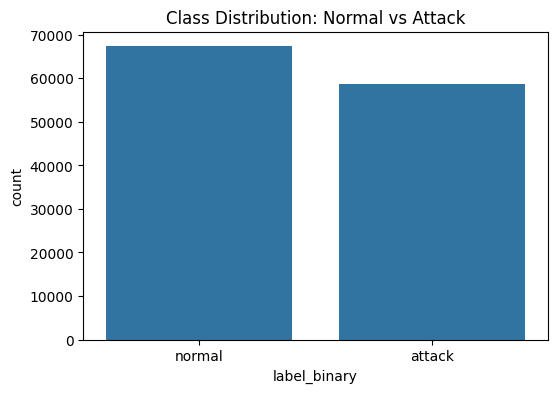

label_binary
normal    0.534583
attack    0.465417
Name: proportion, dtype: float64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Binary label (normal vs attack) for imbalance analysis
df['label_binary'] = df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

plt.figure(figsize=(6,4))
sns.countplot(x='label_binary', data=df)
plt.title('Class Distribution: Normal vs Attack')
plt.savefig('class_distribution.png')
plt.show()

print(df['label_binary'].value_counts(normalize=True))

### 4.2 Attack Category Distribution
Grouping individual attack labels into standard categories (DoS, Probe, R2L, U2R) to better understand class imbalance.

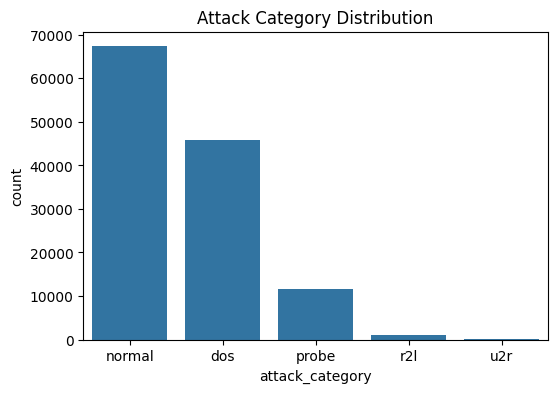

attack_category
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64


In [7]:
# Attack category grouping (standard NSL-KDD mapping)
attack_map = {
    'normal':'normal',
    'neptune':'dos','back':'dos','land':'dos','pod':'dos','smurf':'dos','teardrop':'dos',
    'ipsweep':'probe','nmap':'probe','portsweep':'probe','satan':'probe',
    'ftp_write':'r2l','guess_passwd':'r2l','imap':'r2l','multihop':'r2l',
    'phf':'r2l','spy':'r2l','warezclient':'r2l','warezmaster':'r2l',
    'buffer_overflow':'u2r','loadmodule':'u2r','perl':'u2r','rootkit':'u2r'
}
df['attack_category'] = df['label'].map(attack_map)

plt.figure(figsize=(6,4))
sns.countplot(x='attack_category', data=df, order=df['attack_category'].value_counts().index)
plt.title('Attack Category Distribution')
plt.savefig('attack_category_distribution.png')
plt.show()

print(df['attack_category'].value_counts())

### 4.3 Numeric Feature Distributions
Reviewing summary statistics of the numeric features.

In [8]:
# Numeric feature distributions
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


### 4.4 Outlier Analysis
Checking selected features for outliers using boxplots on a log scale.

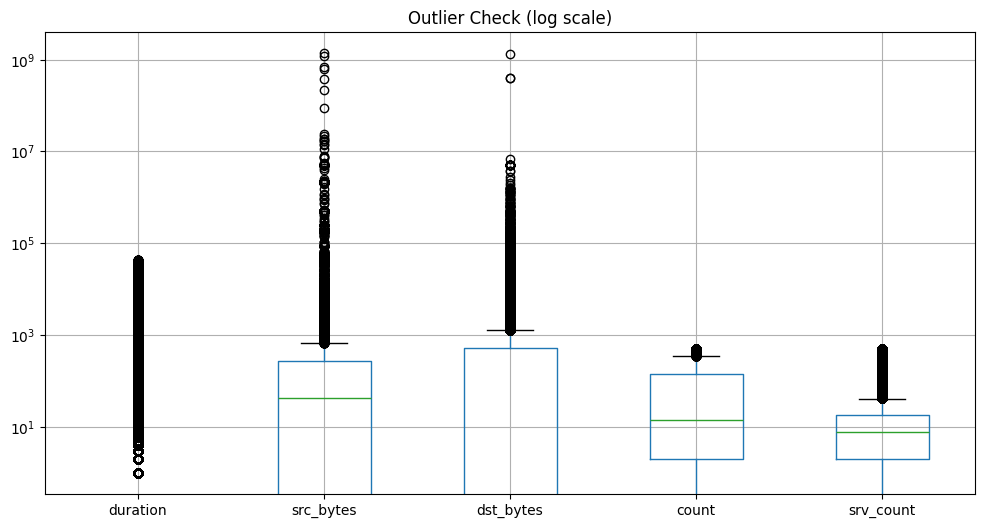

In [9]:
# Outlier check via boxplot on key features
key_features = ['duration','src_bytes','dst_bytes','count','srv_count']
plt.figure(figsize=(12,6))
df[key_features].boxplot()
plt.yscale('log')
plt.title('Outlier Check (log scale)')
plt.savefig('outlier_check.png')
plt.show()

### 4.5 Correlation Analysis
Using Pearson correlation since most features are continuous rate or count-based values.

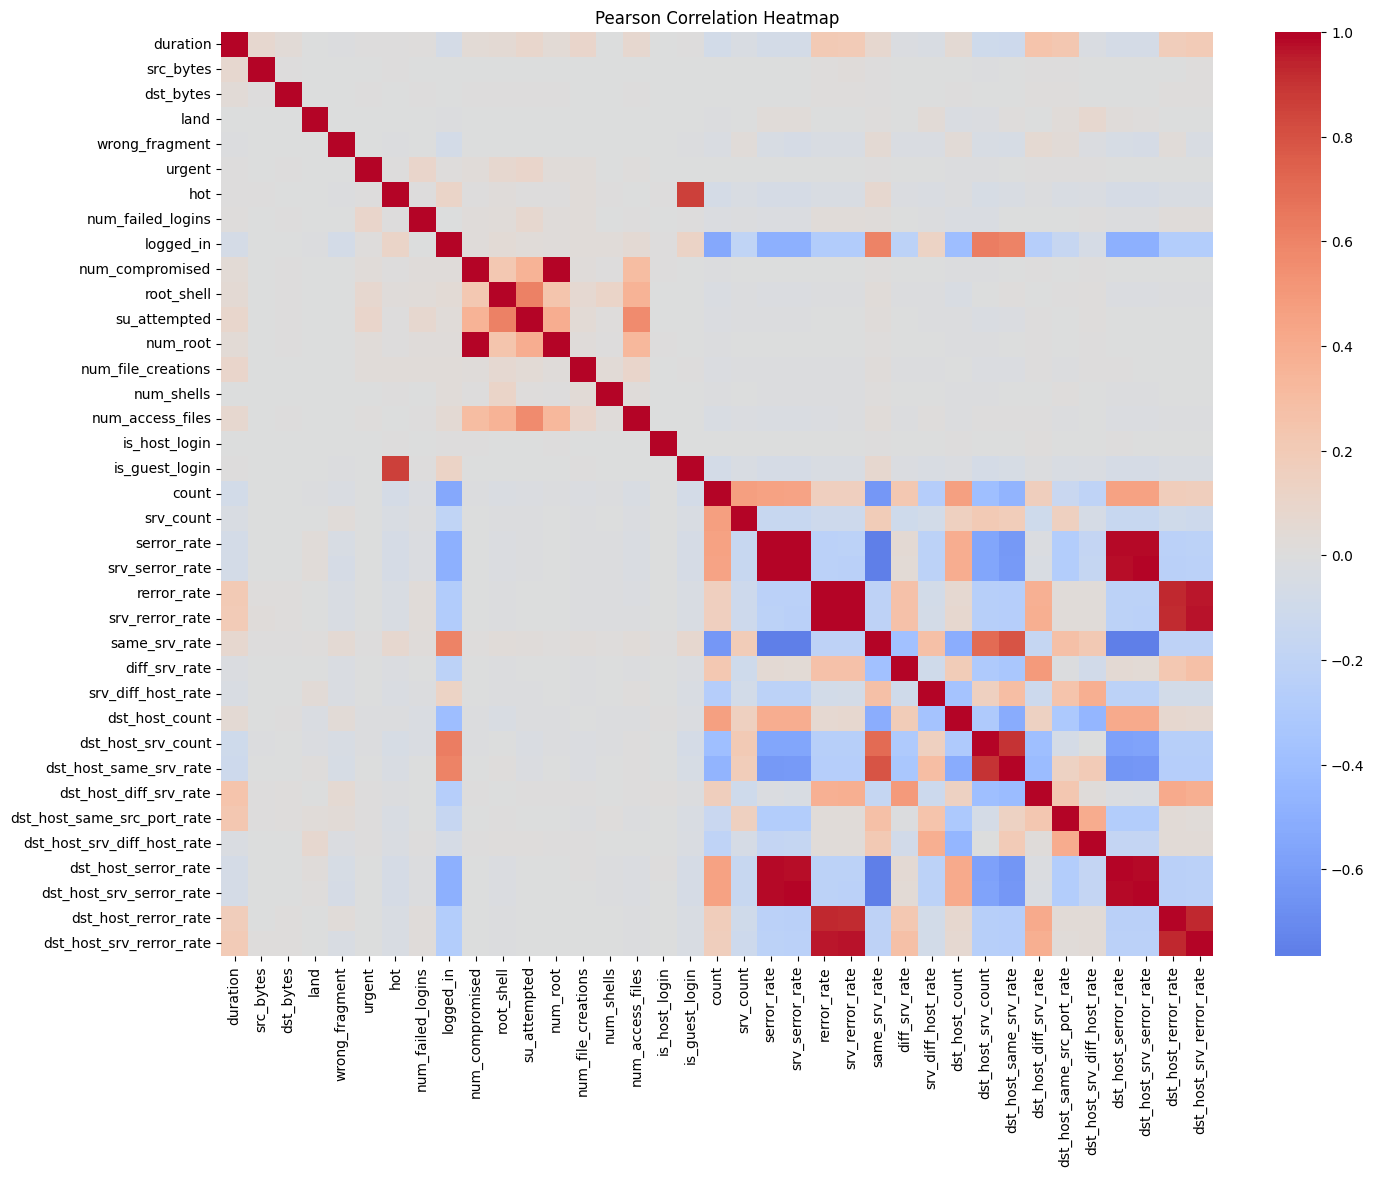

In [10]:
# Correlation analysis (Pearson, since features are mostly continuous rate/count data)
plt.figure(figsize=(16,12))
corr = df[numeric_cols].corr(method='pearson')
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Pearson Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

### 4.6 Categorical Features vs Attack Category
Checking how protocol type and flag relate to different attack categories using crosstabs.

In [11]:
# Categorical vs label crosstab
for col in ['protocol_type','flag']:
    print(f"\n--- {col} vs attack_category ---")
    print(pd.crosstab(df[col], df['attack_category']))


--- protocol_type vs attack_category ---
attack_category    dos  normal  probe  r2l  u2r
protocol_type                                  
icmp              2847    1309   4135    0    0
tcp              42188   53600   5857  995   49
udp                892   12434   1664    0    3

--- flag vs attack_category ---
attack_category    dos  normal  probe  r2l  u2r
flag                                           
OTH                  0      11     35    0    0
REJ               5671    2693   2869    0    0
RSTO              1216     219     80   46    1
RSTOS0               0       0    103    0    0
RSTR                90     146   2180    5    0
S0               34344     354    153    0    0
S1                   2     361      1    1    0
S2                   5     119      2    1    0
S3                   0      45      1    3    0
SF                4599   63393   5967  935   51
SH                   0       2    265    4    0


### 4.7 Class Imbalance Summary
Summarizing the percentage share of each attack category.

In [12]:
# Class imbalance % summary (for report)
print(df['attack_category'].value_counts(normalize=True) * 100)

attack_category
normal    53.458281
dos       36.457812
probe      9.252776
r2l        0.789852
u2r        0.041279
Name: proportion, dtype: float64


### 4.8 Feature Redundancy Check
Identifying pairs of numeric features that are highly correlated with each other (above 0.9), which may indicate redundant information.

In [13]:
# Top correlated features with each other (redundancy check)
corr_matrix = df[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row,col]) for col in upper.columns for row in upper.index if upper.loc[row,col] > 0.9]
high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature1','Feature2','Correlation']).sort_values('Correlation', ascending=False)
print(high_corr_df)

                    Feature1              Feature2  Correlation
0                   num_root       num_compromised     0.998833
1            srv_serror_rate           serror_rate     0.993289
2            srv_rerror_rate           rerror_rate     0.989008
6   dst_host_srv_serror_rate       srv_serror_rate     0.986252
7   dst_host_srv_serror_rate  dst_host_serror_rate     0.985052
5   dst_host_srv_serror_rate           serror_rate     0.981139
3       dst_host_serror_rate           serror_rate     0.979373
4       dst_host_serror_rate       srv_serror_rate     0.977596
11  dst_host_srv_rerror_rate       srv_rerror_rate     0.970208
10  dst_host_srv_rerror_rate           rerror_rate     0.964449
8       dst_host_rerror_rate           rerror_rate     0.926749
12  dst_host_srv_rerror_rate  dst_host_rerror_rate     0.924688
9       dst_host_rerror_rate       srv_rerror_rate     0.917822


## 5. Feature Engineering

### 5.1 Encoding Categorical Features
Encoding protocol_type, service, and flag using label encoding, and handling categories in the test set that were not seen in training.

In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical features (protocol_type, service, flag)
le_dict = {}
for col in ['protocol_type','service','flag']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Test set: handle unseen categories safely
for col in ['protocol_type','service','flag']:
    df_test[col] = df_test[col].map(lambda x: le_dict[col].transform([x])[0] if x in le_dict[col].classes_ else -1)

print(df[['protocol_type','service','flag']].head())

   protocol_type  service  flag
0              1       20     9
1              2       44     9
2              1       49     5
3              1       24     9
4              1       24     9


### 5.2 Encoding the Target Label
Converting the label into a binary target: 0 for normal traffic, 1 for any type of attack.

In [15]:
# Encode label -> binary (normal=0, attack=1) for modeling
df['label_binary_enc'] = df['label'].apply(lambda x: 0 if x=='normal' else 1)
df_test['label_binary_enc'] = df_test['label'].apply(lambda x: 0 if x=='normal' else 1)

print(df['label_binary_enc'].value_counts())

label_binary_enc
0    67343
1    58630
Name: count, dtype: int64


### 5.3 Removing Redundant Features
Dropping the highly correlated features identified earlier to reduce redundancy in the model input.

In [16]:
# Drop redundant highly-correlated features (>0.95 threshold)
redundant_features = ['srv_serror_rate','dst_host_srv_serror_rate','dst_host_serror_rate',
                       'srv_rerror_rate','dst_host_srv_rerror_rate','num_root']

df_model = df.drop(columns=redundant_features + ['label','label_binary','attack_category'])
df_test_model = df_test.drop(columns=redundant_features + ['label'])

print("Final feature shape:", df_model.shape)

Final feature shape: (125973, 35)


### 5.4 Feature Scaling
Scaling the numeric features using StandardScaler before training the models.

In [17]:
# Feature scaling
X = df_model.drop(columns=['label_binary_enc'])
y = df_model['label_binary_enc']

X_test = df_test_model.drop(columns=['label_binary_enc'])
y_test = df_test_model['label_binary_enc']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

print(X_scaled.shape, X_test_scaled.shape)

(125973, 34) (22544, 34)


## 6. Model Training
Training two classifiers: Decision Tree and Random Forest.

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Model 1: Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_scaled, y)

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

print("Both models trained successfully")

Both models trained successfully


### 6.1 Cross-Validation on Training Data
Checking model performance on the training data using 5-fold cross-validation before evaluating on the test set.

In [19]:
# Cross-validation on training set (sanity check before test evaluation)
dt_cv = cross_val_score(dt, X_scaled, y, cv=5, scoring='accuracy')
rf_cv = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy')

print("Decision Tree CV Accuracy:", dt_cv.mean())
print("Random Forest CV Accuracy:", rf_cv.mean())

Decision Tree CV Accuracy: 0.9981107082152244
Random Forest CV Accuracy: 0.9988727755215283


## 7. Evaluation
Evaluating both models on the test set using accuracy, precision, recall, F1 score, MCC, and ROC-AUC. A confusion matrix and classification report are also generated for each model.

In [20]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, matthews_corrcoef, roc_auc_score,
                              confusion_matrix, classification_report)

def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("MCC:", matthews_corrcoef(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    return y_pred

dt_pred = evaluate_model(dt, "Decision Tree", X_test_scaled, y_test)
rf_pred = evaluate_model(rf, "Random Forest", X_test_scaled, y_test)


===== Decision Tree =====
Accuracy: 0.7908977998580553
Precision: 0.9650589987398327
Recall: 0.6564326346138861
F1 Score: 0.7813746405713756
MCC: 0.6353832162215862
ROC-AUC: 0.812923926954584

Confusion Matrix:
 [[9406  305]
 [4409 8424]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.97      0.66      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544


===== Random Forest =====
Accuracy: 0.7751508161816891
Precision: 0.9665865384615384
Recall: 0.626665627678641
F1 Score: 0.7603649600529476
MCC: 0.6136949307738755
ROC-AUC: 0.9577906460472959

Confusion Matrix:
 [[9433  278]
 [4791 8042]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.97      0.79      9711
           1       0.97      0.63 

### 7.1 Confusion Matrix Visualization
Visualizing the confusion matrices for both models side by side.

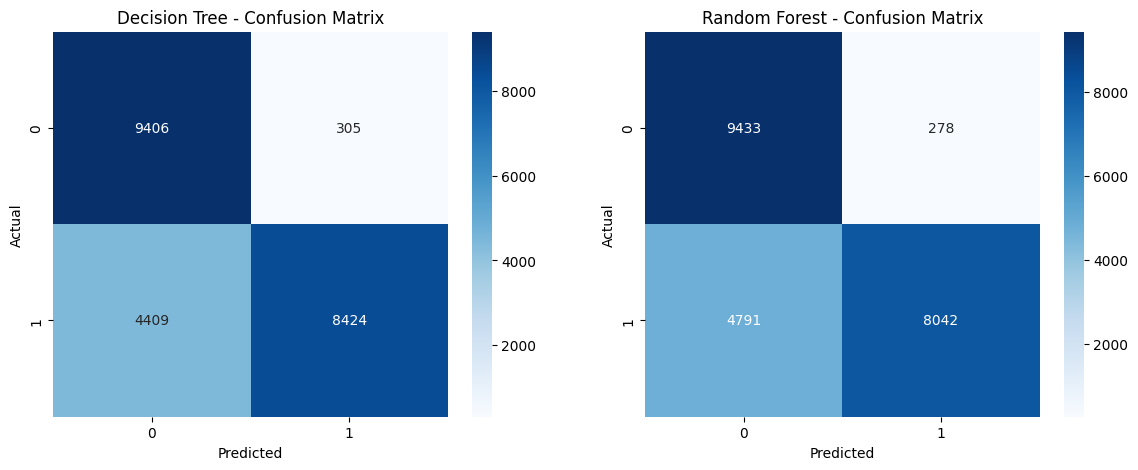

In [21]:
# Confusion matrix visualization
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree - Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.savefig('confusion_matrices.png')
plt.show()

## 8. Error Analysis
Checking which attack categories are misclassified most often by each model.

In [22]:
# Which attack categories are being missed the most?
df_test_analysis = df_test.copy()
df_test_analysis['dt_pred'] = dt_pred
df_test_analysis['rf_pred'] = rf_pred

# Map test labels to categories too
df_test_analysis['attack_category'] = df_test_analysis['label'].map(attack_map)
df_test_analysis['attack_category'] = df_test_analysis['attack_category'].fillna('unknown_new_attack')

print("--- Decision Tree errors by attack category ---")
errors_dt = df_test_analysis[df_test_analysis['label_binary_enc'] != df_test_analysis['dt_pred']]
print(errors_dt['attack_category'].value_counts())

print("\n--- Random Forest errors by attack category ---")
errors_rf = df_test_analysis[df_test_analysis['label_binary_enc'] != df_test_analysis['rf_pred']]
print(errors_rf['attack_category'].value_counts())

--- Decision Tree errors by attack category ---
attack_category
unknown_new_attack    2302
r2l                   1845
normal                 305
dos                    226
u2r                     31
probe                    5
Name: count, dtype: int64

--- Random Forest errors by attack category ---
attack_category
unknown_new_attack    2646
r2l                   2071
normal                 278
dos                     40
u2r                     34
Name: count, dtype: int64


### 8.1 Checking for Unseen Attack Types
Comparing the attack labels present in the test set against those present in the training set, to check whether the drop in test accuracy is related to attack types the model never saw during training.

In [23]:
# Check for labels in test set NOT present in training set (root cause)
train_labels = set(df['label'].unique())
test_labels = set(df_test['label'].unique())
new_attacks_in_test = test_labels - train_labels

print("Attack types in TEST but NOT in TRAIN:", new_attacks_in_test)
print("Count of these unseen-attack rows in test set:", df_test[df_test['label'].isin(new_attacks_in_test)].shape[0])

Attack types in TEST but NOT in TRAIN: {'processtable', 'worm', 'sendmail', 'udpstorm', 'xsnoop', 'httptunnel', 'ps', 'xlock', 'named', 'saint', 'mscan', 'apache2', 'snmpgetattack', 'xterm', 'sqlattack', 'snmpguess', 'mailbomb'}
Count of these unseen-attack rows in test set: 3750


## 9. Saving Outputs
Saving the generated plots and the trained models for reference.

In [24]:
import shutil
from google.colab import files
import joblib

# Save trained models
joblib.dump(dt, 'decision_tree_model.pkl')
joblib.dump(rf, 'random_forest_model.pkl')

# Save the cleaned/processed dataset (optional, useful for report/reproducibility)
df.to_csv('processed_train_data.csv', index=False)

# Create a folder and move everything into it
import os
os.makedirs('project_outputs', exist_ok=True)

files_to_zip = [
    'class_distribution.png',
    'attack_category_distribution.png',
    'outlier_check.png',
    'correlation_heatmap.png',
    'confusion_matrices.png',
    'decision_tree_model.pkl',
    'random_forest_model.pkl',
    'processed_train_data.csv'
]

for f in files_to_zip:
    if os.path.exists(f):
        shutil.copy(f, f'project_outputs/{f}')
    else:
        print(f"Warning: {f} not found, skipping")

# Zip everything
shutil.make_archive('NSL_KDD_Project_Outputs', 'zip', 'project_outputs')

# Download the zip
files.download('NSL_KDD_Project_Outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Conclusion
Both models achieved high accuracy during cross-validation on the training data, but their performance dropped noticeably on the test set. Error analysis showed that many of the missed cases belonged to attack types that were not present in the training data, which explains most of this gap. Random Forest did not clearly outperform Decision Tree on the test set despite having a higher training score, showing that higher training accuracy alone does not guarantee better generalization on unseen attacks.